# 预训练模型与迁移学习

训练卷积神经网络（CNN）可能需要耗费大量时间，并且需要大量数据。然而，大部分时间实际上是用来学习网络用来从图像中提取模式的最佳低级滤波器。这时，一个自然的问题就出现了——我们是否可以使用在一个数据集上训练好的神经网络，并将其适配到对不同图像的分类任务，而无需完整的训练过程？

这种方法被称为**迁移学习**，因为我们将一个神经网络模型中的部分知识迁移到另一个模型中。在迁移学习中，我们通常从一个预训练模型开始，这个模型已经在某个大型图像数据集（例如 **ImageNet**）上进行了训练。这些模型已经能够很好地从通用图像中提取不同的特征，在许多情况下，仅仅在这些提取的特征之上构建一个分类器就能取得不错的效果。


In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchinfo import summary
import numpy as np
import os

from pytorchcv import train, plot_results, display_dataset, train_long, check_image_dir

## 猫与狗数据集

在本单元中，我们将解决一个实际问题——对猫和狗的图像进行分类。为此，我们将使用 [Kaggle Cats vs. Dogs Dataset](https://www.kaggle.com/c/dogs-vs-cats)，该数据集也可以从 [Microsoft](https://www.microsoft.com/en-us/download/details.aspx?id=54765) 下载。

让我们下载这个数据集并将其解压到 `data` 目录中（这个过程可能需要一些时间！）：


In [3]:
if not os.path.exists('data/kagglecatsanddogs_5340.zip'):
    !wget -P data https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

'wget' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���


In [15]:
import zipfile
if not os.path.exists('data/PetImages'):
    with zipfile.ZipFile('data/kagglecatsanddogs_5340.zip', 'r') as zip_ref:
        zip_ref.extractall('data')

不幸的是，数据集中有一些损坏的图像文件。我们需要快速清理以检查损坏的文件。为了不影响本教程，我们将验证数据集的代码移到了一个模块中。


In [16]:
check_image_dir('data/PetImages/Cat/*.jpg')
check_image_dir('data/PetImages/Dog/*.jpg')

Corrupt image: data/PetImages/Cat\666.jpg
Corrupt image: data/PetImages/Dog\11702.jpg


D:\Anaconda\envs\ai4beg\Lib\site-packages\PIL\TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))


接下来，让我们将图像加载到PyTorch数据集，转换为张量并进行一些归一化处理。我们将应用`std_normalize`变换，将图像调整到预训练的VGG网络所期望的范围：


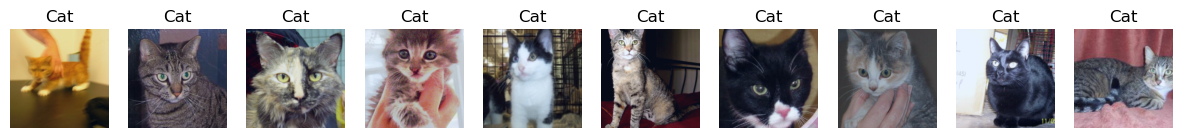

In [18]:
std_normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
trans = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(), 
        std_normalize])
dataset = torchvision.datasets.ImageFolder('data/PetImages',transform=trans)
#imagefolder可以帮助标好label，
trainset, testset = torch.utils.data.random_split(dataset,[20000,len(dataset)-20000])

display_dataset(dataset,classes=dataset.classes)

## 预训练模型

`torchvision` 模块中提供了许多不同的预训练模型，此外在互联网上还能找到更多模型。下面我们来看一下如何加载和使用最简单的 VGG-16 模型：


In [20]:
vgg = torchvision.models.vgg16(pretrained=True)
sample_image = dataset[0][0].unsqueeze(0)
#dataset[i]对应样本，0是图片，1是label
print(sample_image.size())
res = vgg(sample_image)
print(res[0].argmax())

torch.Size([1, 3, 224, 224])
tensor(282)


我们收到的结果是一个 `ImageNet` 类的编号，可以在[这里](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a)查阅。我们可以使用以下代码自动加载此类表并返回结果：


In [22]:
import json, requests
class_map = json.loads(requests.get("https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json").text)
class_map = { int(k) : v for k,v in class_map.items() }

class_map[res[0].argmax().item()]

['n02123159', 'tiger_cat']

让我们也看看VGG-16网络的架构：


In [21]:
summary(vgg,input_size=(1,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 1000]                 --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         1,792
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         36,928
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        73,856
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        147,584
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]          29

除了我们已经了解的层之外，还有一种叫做 **Dropout** 的层类型。这些层是一种 **正则化** 技术。正则化会对学习算法进行轻微修改，使模型能够更好地泛化。在训练过程中，Dropout 层会丢弃上一层中一定比例（大约 30%）的神经元，并在没有这些神经元的情况下进行训练。这有助于优化过程摆脱局部最小值，并在不同的神经路径之间分配决策能力，从而提高网络的整体稳定性。

## GPU计算

深度神经网络，例如 VGG-16 和其他更现代的架构，需要相当大的计算能力来运行。如果有 GPU 加速可用，使用它是很有意义的。为了实现这一点，我们需要显式地将计算中涉及的所有张量移动到 GPU。

通常的做法是在代码中检查 GPU 的可用性，并定义一个指向计算设备的 `device` 变量——可以是 GPU 或 CPU。


In [23]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print('Doing computations on device = {}'.format(device))

vgg.to(device)
sample_image = sample_image.to(device)

vgg(sample_image).argmax()

Doing computations on device = cpu


tensor(282)

## 提取 VGG 特征

如果我们想使用 VGG-16 从图像中提取特征，我们需要一个没有最终分类层的模型。实际上，这个“特征提取器”可以通过 `vgg.features` 方法获得：


torch.Size([1, 512, 7, 7])


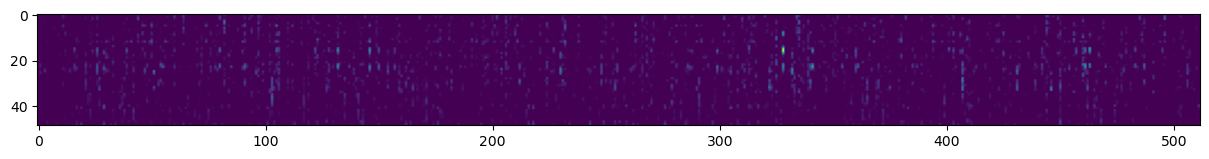

In [24]:
res = vgg.features(sample_image).cpu()
plt.figure(figsize=(15,3))
plt.imshow(res.detach().view(512,-1).T)
print(res.size())

特征张量的维度是 512x7x7，但为了可视化，我们需要将其重塑为二维形式。

现在让我们尝试看看这些特征是否可以用于图像分类。我们将手动选取一部分图像（在我们的例子中是 800 张），并预先计算它们的特征向量。我们会将结果存储在一个大的张量中，称为 `feature_tensor`，同时将标签存储到 `label_tensor` 中：


In [25]:
bs = 8
dl = torch.utils.data.DataLoader(dataset,batch_size=bs,shuffle=True)
num = bs*100
feature_tensor = torch.zeros(num,512*7*7).to(device)
label_tensor = torch.zeros(num).to(device)
i = 0
for x,l in dl:
    with torch.no_grad():
        f = vgg.features(x.to(device))
        feature_tensor[i:i+bs] = f.view(bs,-1)
        label_tensor[i:i+bs] = l
        i+=bs
        print('.',end='')
        if i>=num:
            break


....................................................................................................

现在我们可以定义`vgg_dataset`，从这个张量中获取数据，使用`random_split`函数将其分为训练集和测试集，并在提取的特征之上训练一个小型单层密集分类器网络：


In [26]:
vgg_dataset = torch.utils.data.TensorDataset(feature_tensor,label_tensor.to(torch.long))
train_ds, test_ds = torch.utils.data.random_split(vgg_dataset,[700,100])

train_loader = torch.utils.data.DataLoader(train_ds,batch_size=32)
test_loader = torch.utils.data.DataLoader(test_ds,batch_size=32)

net = torch.nn.Sequential(torch.nn.Linear(512*7*7,2),torch.nn.LogSoftmax()).to(device)

history = train(net,train_loader,test_loader)

D:\Anaconda\envs\ai4beg\Lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch  0, Train acc=0.947, Val acc=0.970, Train loss=0.024, Val loss=0.019
Epoch  1, Train acc=0.983, Val acc=0.990, Train loss=0.009, Val loss=0.009
Epoch  2, Train acc=0.993, Val acc=0.990, Train loss=0.007, Val loss=0.014
Epoch  3, Train acc=0.997, Val acc=0.980, Train loss=0.001, Val loss=0.015
Epoch  4, Train acc=0.993, Val acc=0.980, Train loss=0.004, Val loss=0.011
Epoch  5, Train acc=0.999, Val acc=0.990, Train loss=0.000, Val loss=0.007
Epoch  6, Train acc=1.000, Val acc=0.990, Train loss=0.000, Val loss=0.001
Epoch  7, Train acc=1.000, Val acc=0.990, Train loss=0.000, Val loss=0.000
Epoch  8, Train acc=1.000, Val acc=0.990, Train loss=0.000, Val loss=0.000
Epoch  9, Train acc=1.000, Val acc=0.990, Train loss=0.000, Val loss=0.000


结果非常棒，我们几乎可以以98%的概率区分猫和狗！然而，我们仅在所有图像的小部分上测试了这种方法，因为手动提取特征似乎非常耗时。

## 使用一个VGG网络进行迁移学习

我们还可以通过在训练过程中使用完整的原始VGG-16网络，来避免手动预先计算特征。让我们来看一下VGG-16对象的结构：


In [27]:
print(vgg)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

您可以看到网络包含以下部分：
* 特征提取器 (`features`)，由多个卷积层和池化层组成
* 平均池化层 (`avgpool`)
* 最终的 `classifier`，由几个全连接层组成，将25088个输入特征转换为1000个类别（即ImageNet中的类别数量）

为了训练端到端的模型以对我们的数据集进行分类，我们需要：
* **替换最终的分类器**，使其能够生成所需的类别数量。在我们的例子中，可以使用一个具有25088个输入和2个输出神经元的`Linear`层。
* **冻结卷积特征提取器的权重**，使其不参与训练。建议初始阶段进行权重冻结，因为否则未训练的分类器层可能会破坏卷积提取器的原始预训练权重。冻结权重可以通过将所有参数的`requires_grad`属性设置为`False`来实现。


In [15]:
vgg.classifier = torch.nn.Linear(25088,2).to(device)

for x in vgg.features.parameters():
    x.requires_grad = False

summary(vgg,(1, 3,244,244))

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      --                        --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 244, 244]         (1,792)
│    └─ReLU: 2-2                         [1, 64, 244, 244]         --
│    └─Conv2d: 2-3                       [1, 64, 244, 244]         (36,928)
│    └─ReLU: 2-4                         [1, 64, 244, 244]         --
│    └─MaxPool2d: 2-5                    [1, 64, 122, 122]         --
│    └─Conv2d: 2-6                       [1, 128, 122, 122]        (73,856)
│    └─ReLU: 2-7                         [1, 128, 122, 122]        --
│    └─Conv2d: 2-8                       [1, 128, 122, 122]        (147,584)
│    └─ReLU: 2-9                         [1, 128, 122, 122]        --
│    └─MaxPool2d: 2-10                   [1, 128, 61, 61]          --
│    └─Conv2d: 2-11                      [1, 256, 61, 61]    

从总结中可以看出，这个模型总共有大约1500万个参数，但其中只有5万个是可训练的——这些是分类层的权重。这是个好消息，因为我们可以用更少的样本来微调更少的参数。

现在让我们使用原始数据集来训练模型。这个过程会花费很长时间，因此我们将使用 `train_long` 函数，它会在每个周期结束前打印一些中间结果。强烈建议在支持GPU的计算设备上运行这次训练！


In [16]:
trainset, testset = torch.utils.data.random_split(dataset,[20000,len(dataset)-20000])
train_loader = torch.utils.data.DataLoader(trainset,batch_size=16)
test_loader = torch.utils.data.DataLoader(testset,batch_size=16)

train_long(vgg,train_loader,test_loader,loss_fn=torch.nn.CrossEntropyLoss(),epochs=1,print_freq=90)

Epoch 0, minibatch 0: train acc = 0.5, train loss = 0.0431101992726326
Epoch 0, minibatch 90: train acc = 0.9539835164835165, train loss = 0.0960497070144821


/anaconda/envs/py38_pytorch/lib/python3.8/site-packages/PIL/TiffImagePlugin.py:793: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 0, minibatch 180: train acc = 0.9582182320441989, train loss = 0.12481052967724879
Epoch 0, minibatch 270: train acc = 0.9587177121771218, train loss = 0.14185787918822793
Epoch 0, minibatch 360: train acc = 0.9634695290858726, train loss = 0.14566257719848294
Epoch 0, minibatch 450: train acc = 0.966879157427938, train loss = 0.13402751914149114
Epoch 0, minibatch 540: train acc = 0.9686922365988909, train loss = 0.13931148902766144
Epoch 0, minibatch 630: train acc = 0.9694928684627575, train loss = 0.1386710044510202
Epoch 0, minibatch 720: train acc = 0.970613730929265, train loss = 0.13363790313678375
Epoch 0, minibatch 810: train acc = 0.9709463625154131, train loss = 0.1342217084364885
Epoch 0, minibatch 900: train acc = 0.9721143174250833, train loss = 0.13233261023721474
Epoch 0, minibatch 990: train acc = 0.9726286579212916, train loss = 0.1334670727957871
Epoch 0, minibatch 1080: train acc = 0.9733464384828863, train loss = 0.13777193110039893
Epoch 0, minibatch 1170: 

看起来我们已经获得了一个相当准确的猫狗分类器！让我们保存它以备将来使用！


In [17]:
torch.save(vgg,'data/cats_dogs.pth')

我们可以随时从文件中加载模型。您可能会发现这很有用，以防下一个实验破坏模型——您不必从头开始重新启动。


In [18]:
vgg = torch.load('data/cats_dogs.pth')

## 微调迁移学习

在上一节中，我们已经训练了最终的分类器层，用于对我们自己的数据集中的图像进行分类。然而，我们并没有重新训练特征提取器，模型依赖于它在 ImageNet 数据中学到的特征。如果你的目标物体在视觉上与普通的 ImageNet 图像有较大差异，这种特征组合可能无法达到最佳效果。因此，开始训练卷积层是合理的选择。

为此，我们可以解冻之前冻结的卷积滤波器参数。

> **注意：** 首先冻结参数并进行几个训练周期以稳定分类层的权重是非常重要的。如果直接开始训练端到端网络并解冻参数，可能会因为较大的误差破坏卷积层中的预训练权重。


In [19]:
for x in vgg.features.parameters():
    x.requires_grad = True

在解冻后，我们可以进行更多轮的训练。你也可以选择较低的学习率，以尽量减少对预训练权重的影响。然而，即使使用较低的学习率，你仍然可以预期在训练初期准确率会有所下降，直到最终达到比固定权重情况下稍高的水平。

> **Note:** 这种训练速度会慢很多，因为我们需要将梯度反向传播通过网络的许多层！你可能需要观察前几个小批量数据的趋势，然后再决定是否停止计算。


In [20]:
train_long(vgg,train_loader,test_loader,loss_fn=torch.nn.CrossEntropyLoss(),epochs=1,print_freq=90,lr=0.0001)

Epoch 0, minibatch 0: train acc = 1.0, train loss = 0.0
Epoch 0, minibatch 90: train acc = 0.8990384615384616, train loss = 0.2978392171335744
Epoch 0, minibatch 180: train acc = 0.9060773480662984, train loss = 0.1658294214069514
Epoch 0, minibatch 270: train acc = 0.9102859778597786, train loss = 0.11819224340009514
Epoch 0, minibatch 360: train acc = 0.9191481994459834, train loss = 0.09244130522920814
Epoch 0, minibatch 450: train acc = 0.9261363636363636, train loss = 0.07583886292451236
Epoch 0, minibatch 540: train acc = 0.928373382624769, train loss = 0.06537413817456822
Epoch 0, minibatch 630: train acc = 0.9318541996830428, train loss = 0.057419379426257924
Epoch 0, minibatch 720: train acc = 0.9361130374479889, train loss = 0.05114534460059813
Epoch 0, minibatch 810: train acc = 0.938347718865598, train loss = 0.04657612246737968
Epoch 0, minibatch 900: train acc = 0.9407602663706992, train loss = 0.04258851655712403
Epoch 0, minibatch 990: train acc = 0.9431130171543896, tr

## 其他计算机视觉模型

VGG-16 是最简单的计算机视觉架构之一。`torchvision` 包提供了许多其他预训练网络。其中最常用的是微软开发的 **ResNet** 架构和谷歌的 **Inception**。例如，让我们来探索最简单的 ResNet-18 模型的架构（ResNet 是一个具有不同深度的模型家族，如果你想看看一个真正深度的模型，可以尝试 ResNet-151）：


In [21]:
resnet = torchvision.models.resnet18()
print(resnet)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

正如你所见，这个模型包含相同的构建模块：特征提取器和最终分类器（`fc`）。这使得我们可以像使用 VGG-16 进行迁移学习一样使用这个模型。你可以尝试使用不同的 ResNet 模型作为基础模型，实验上述代码，并观察准确率的变化。

## 批量归一化

这个网络还包含另一种类型的层：**批量归一化**。批量归一化的核心思想是将通过神经网络的数据调整到合适的区间。通常，神经网络在所有值都处于 [-1,1] 或 [0,1] 范围内时效果最佳，这也是我们对输入数据进行缩放或归一化的原因。然而，在深度网络的训练过程中，可能会出现数据值显著超出这个范围的情况，这会导致训练变得困难。批量归一化层会计算当前小批量数据的平均值和标准差，并利用这些值在信号通过神经网络层之前对其进行归一化处理。这显著提高了深度网络的稳定性。


## 要点

通过迁移学习，我们能够快速构建一个用于自定义对象分类任务的分类器，并且取得了较高的准确率。然而，这个例子并不完全公平，因为原始的 VGG-16 网络是预训练用于识别猫和狗的，因此我们只是重用了网络中已经存在的大部分模式。对于更为特殊的领域特定对象（例如工厂生产线上的细节或不同种类的树叶），你可以预期准确率会更低。

你可以看到，我们现在正在解决的更复杂任务需要更高的计算能力，无法轻松地在 CPU 上完成。在下一单元中，我们将尝试使用更轻量化的实现来训练相同的模型，利用更少的计算资源，这样虽然会导致准确率略有下降，但仍能取得不错的效果。



---

**免责声明**：  
本文档使用AI翻译服务 [Co-op Translator](https://github.com/Azure/co-op-translator) 进行翻译。尽管我们努力确保翻译的准确性，但请注意，自动翻译可能包含错误或不准确之处。原始语言的文档应被视为权威来源。对于关键信息，建议使用专业人工翻译。我们不对因使用此翻译而产生的任何误解或误读承担责任。
